In [1]:
from warnings import filterwarnings; filterwarnings("ignore")
import joblib
import pandas as pd
import numpy as np
import pandas, numpy
import matplotlib.pyplot as plt

from catboost import CatBoostRegressor, Pool
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.ensemble import StackingRegressor

from sklearn.linear_model import RidgeCV
from sklearn.linear_model import ElasticNetCV
from sklearn.linear_model import LassoCV
from sklearn.linear_model import LassoLars

from sklearn.metrics import mean_absolute_percentage_error
from sklearn.impute import SimpleImputer

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

In [2]:
class DataPreprocessing:
    def __init__(self, train, test):
        self.target = "ghi"
        self.column_drop = "timestamp"
        
        # Store original data with proper column handling
        self.train_original = train.copy()
        self.test_original = test.copy()
        
        # Handle unnamed columns and basic cleaning
        if 'Unnamed: 0' in train.columns:
            self.train = train.drop(columns=['Unnamed: 0'])
            self.test = test.drop(columns=['Unnamed: 0'])
        else:
            self.train = train.copy()
            self.test = test.copy()
        
        # Initial data cleaning - keep all rows for solar forecasting
        # Only drop rows where timestamp is missing (critical for time series)
        self.train = self.train.dropna(subset=['timestamp'])
        self.test = self.test.dropna(subset=['timestamp'])
        
        print(f"Training data shape: {self.train.shape}")
        print(f"Test data shape: {self.test.shape}")
        
        # Execute preprocessing pipeline
        self.feature_extraction()
        self.handle_solar_specific_features()
        self.handle_missing_values()
        self.train_test_split()
        self.normalise_encode()
        
    def feature_extraction(self):
        """Advanced feature extraction for solar forecasting with astronomical and meteorological features"""
        # Convert timestamp to datetime
        self.train['timestamp'] = pd.to_datetime(self.train['timestamp'])
        self.test['timestamp'] = pd.to_datetime(self.test['timestamp'])
        
        for df in [self.train, self.test]:
            # Basic time features
            df['timestamp_year'] = df['timestamp'].dt.year
            df['timestamp_month'] = df['timestamp'].dt.month
            df['timestamp_day'] = df['timestamp'].dt.day
            df['timestamp_hour'] = df['timestamp'].dt.hour
            df['timestamp_minute'] = df['timestamp'].dt.minute
            
            # Extended temporal features
            df['day_of_year'] = df['timestamp'].dt.dayofyear
            df['week_of_year'] = df['timestamp'].dt.isocalendar().week
            df['day_of_week'] = df['timestamp'].dt.dayofweek
            df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
            df['quarter'] = df['timestamp'].dt.quarter
            
            # Time periods (useful for different solar patterns)
            df['is_morning'] = ((df['timestamp_hour'] >= 6) & (df['timestamp_hour'] < 12)).astype(int)
            df['is_afternoon'] = ((df['timestamp_hour'] >= 12) & (df['timestamp_hour'] < 18)).astype(int)
            df['is_evening'] = ((df['timestamp_hour'] >= 18) & (df['timestamp_hour'] < 22)).astype(int)
            df['is_night'] = ((df['timestamp_hour'] >= 22) | (df['timestamp_hour'] < 6)).astype(int)
            
            # Peak solar hours (typically 10 AM to 4 PM)
            df['is_peak_solar'] = ((df['timestamp_hour'] >= 10) & (df['timestamp_hour'] <= 16)).astype(int)
            df['hours_from_solar_noon'] = np.abs(df['timestamp_hour'] - 12)
            
            # Cyclical encoding for periodic features (preserves continuity)
            df['hour_sin'] = np.sin(2 * np.pi * df['timestamp_hour'] / 24)
            df['hour_cos'] = np.cos(2 * np.pi * df['timestamp_hour'] / 24)
            df['day_sin'] = np.sin(2 * np.pi * df['day_of_year'] / 365.25)
            df['day_cos'] = np.cos(2 * np.pi * df['day_of_year'] / 365.25)
            df['month_sin'] = np.sin(2 * np.pi * df['timestamp_month'] / 12)
            df['month_cos'] = np.cos(2 * np.pi * df['timestamp_month'] / 12)
            df['week_sin'] = np.sin(2 * np.pi * df['week_of_year'] / 52)
            df['week_cos'] = np.cos(2 * np.pi * df['week_of_year'] / 52)
            df['day_of_week_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
            df['day_of_week_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)
            
            # Season encoding with more granular approach
            df['season'] = ((df['timestamp_month'] % 12) // 3)
            df['is_summer'] = (df['season'] == 1).astype(int)  # Jun-Aug
            df['is_winter'] = (df['season'] == 3).astype(int)  # Dec-Feb
            df['is_spring'] = (df['season'] == 0).astype(int)  # Mar-May
            df['is_autumn'] = (df['season'] == 2).astype(int)  # Sep-Nov
            
            # Solar geometry features (assuming Northern Hemisphere)
            # Solar declination angle approximation
            df['solar_declination'] = 23.45 * np.sin(np.radians(360 * (284 + df['day_of_year']) / 365))
            
            # Hour angle (solar position)
            df['hour_angle'] = 15 * (df['timestamp_hour'] - 12)  # degrees from solar noon
            
            # Solar elevation angle approximation (assuming latitude ~23°N for India)
            latitude = 23.0  # Approximate latitude for India
            df['solar_elevation'] = np.arcsin(
                np.sin(np.radians(latitude)) * np.sin(np.radians(df['solar_declination'])) +
                np.cos(np.radians(latitude)) * np.cos(np.radians(df['solar_declination'])) * 
                np.cos(np.radians(df['hour_angle']))
            ) * 180 / np.pi  # Convert to degrees
            
            # Solar elevation bounded (no negative values)
            df['solar_elevation_positive'] = np.maximum(df['solar_elevation'], 0)
            
            # Air mass approximation (affects solar radiation)
            df['air_mass'] = np.where(
                df['solar_elevation_positive'] > 0,
                1 / (np.sin(np.radians(df['solar_elevation_positive'])) + 
                     0.50572 * (df['solar_elevation_positive'] + 6.07995) ** -1.6364),
                np.inf
            )
            df['air_mass'] = np.where(df['air_mass'] == np.inf, 50, df['air_mass'])  # Cap extreme values
            df['air_mass'] = np.minimum(df['air_mass'], 50)  # Cap at reasonable maximum
            
            # Extraterrestrial radiation (theoretical maximum)
            solar_constant = 1367  # W/m²
            df['extraterrestrial_radiation'] = solar_constant * (
                1 + 0.033 * np.cos(2 * np.pi * df['day_of_year'] / 365)
            ) * np.maximum(np.sin(np.radians(df['solar_elevation'])), 0)
            
            # Clear sky index approximation
            df['theoretical_clear_sky_ghi'] = df['extraterrestrial_radiation'] * 0.75 ** (df['air_mass'] ** 0.678)
            
            # Sunshine duration indicator
            df['potential_sunshine_hours'] = np.where(df['solar_elevation_positive'] > 0, 1, 0)
            
            # Rolling time features (lag features for temporal patterns)
            df['hour_of_day_numeric'] = df['timestamp_hour'] + df['timestamp_minute'] / 60.0
            
            # Calendar features
            df['days_since_winter_solstice'] = np.where(
                df['day_of_year'] >= 355,  # After Dec 21
                df['day_of_year'] - 355,
                df['day_of_year'] + 10  # Before Dec 21 of next year
            )
            
            df['days_since_summer_solstice'] = np.where(
                df['day_of_year'] >= 172,  # After June 21
                df['day_of_year'] - 172,
                df['day_of_year'] + 193  # Before June 21
            )
            
            # Solar intensity category (based on hour and season)
            df['solar_intensity_category'] = 0  # Night
            df.loc[(df['timestamp_hour'].between(6, 8)) | (df['timestamp_hour'].between(16, 18)), 'solar_intensity_category'] = 1  # Low
            df.loc[(df['timestamp_hour'].between(9, 11)) | (df['timestamp_hour'].between(13, 15)), 'solar_intensity_category'] = 2  # Medium
            df.loc[df['timestamp_hour'].between(11, 13), 'solar_intensity_category'] = 3  # High
            
            # Interaction features between time and season
            df['hour_season_interaction'] = df['timestamp_hour'] * df['season']
            df['day_of_year_hour_interaction'] = df['day_of_year'] * df['timestamp_hour'] / 365.25
            
            # Create time-based groups for statistical features later
            df['time_group'] = df['timestamp_hour'].astype(str) + '_' + df['timestamp_month'].astype(str)
            df['seasonal_hour'] = df['season'].astype(str) + '_' + df['timestamp_hour'].astype(str)
        
        print(f"Advanced feature extraction completed. Created {len([col for col in self.train.columns if col not in ['timestamp', self.target]])} features.")
        
        # Print some key solar features for verification
        print("Key solar features created:")
        print("- Solar elevation and air mass calculations")
        print("- Extraterrestrial radiation estimates") 
        print("- Cyclical time encodings")
        print("- Solar intensity categorization")
        print("- Astronomical position features")
    
    def handle_solar_specific_features(self):
        """Advanced solar-specific feature engineering with meteorological and physical relationships"""
        for df in [self.train, self.test]:
            # =============================================================================
            # ATMOSPHERIC AND WEATHER CONDITIONS
            # =============================================================================
            
            # Enhanced clear sky indicators
            if 'relative_humidity' in df.columns and 'wind_speed' in df.columns:
                # Clear sky probability (low humidity + moderate wind)
                df['clear_sky_index'] = (100 - df['relative_humidity']) / 100 * np.minimum(df['wind_speed'] / 5, 1)
                
                # Cloud cover estimation (inverse of clear sky)
                df['cloud_cover_estimate'] = 1 - df['clear_sky_index']
                
                # Atmospheric stability indicator
                df['atmospheric_stability'] = df['relative_humidity'] * (1 / (df['wind_speed'] + 0.1))
            
            # Dew point calculation (if temperature and humidity available)
            if 'ambient_temperature' in df.columns and 'relative_humidity' in df.columns:
                # Magnus formula for dew point
                a, b, c = 17.27, 237.7, 243.5
                alpha = ((a * df['ambient_temperature']) / (b + df['ambient_temperature'])) + np.log(df['relative_humidity'] / 100.0)
                df['dew_point'] = (b * alpha) / (a - alpha)
                
                # Temperature-dew point spread (indicator of fog/cloud formation)
                df['temp_dewpoint_spread'] = df['ambient_temperature'] - df['dew_point']
                
                # Relative humidity categories - FIXED: Handle NaN values
                df['humidity_category'] = pd.cut(df['relative_humidity'], 
                                               bins=[0, 30, 60, 80, 100], 
                                               labels=[0, 1, 2, 3], 
                                               include_lowest=True)
                df['humidity_category'] = df['humidity_category'].fillna(1).astype(int)  # Default to category 1
            
            # =============================================================================
            # WIND ANALYSIS
            # =============================================================================
            
            if 'wind_direction' in df.columns:
                # Enhanced wind direction encoding (cyclical)
                df['wind_dir_sin'] = np.sin(2 * np.pi * df['wind_direction'] / 360)
                df['wind_dir_cos'] = np.cos(2 * np.pi * df['wind_direction'] / 360)
                
                # Cardinal direction indicators
                df['wind_north'] = ((df['wind_direction'] >= 337.5) | (df['wind_direction'] < 22.5)).astype(int)
                df['wind_south'] = ((df['wind_direction'] >= 157.5) & (df['wind_direction'] < 202.5)).astype(int)
                df['wind_east'] = ((df['wind_direction'] >= 67.5) & (df['wind_direction'] < 112.5)).astype(int)
                df['wind_west'] = ((df['wind_direction'] >= 247.5) & (df['wind_direction'] < 292.5)).astype(int)
            
            if 'wind_speed' in df.columns:
                # Wind speed categories (Beaufort-like scale) - FIXED: Handle NaN values
                df['wind_speed_category'] = pd.cut(df['wind_speed'], 
                                                 bins=[0, 2, 5, 8, 12, 100], 
                                                 labels=[0, 1, 2, 3, 4], 
                                                 include_lowest=True)
                df['wind_speed_category'] = df['wind_speed_category'].fillna(1).astype(int)  # Default to category 1
                
                # Wind power (cubic relationship)
                df['wind_power'] = df['wind_speed'] ** 3
                
                # Calm vs windy conditions
                df['is_calm'] = (df['wind_speed'] < 2).astype(int)
                df['is_windy'] = (df['wind_speed'] > 8).astype(int)
            
            # =============================================================================
            # TEMPERATURE ANALYSIS
            # =============================================================================
            
            # Module temperature analysis
            module_temp_cols = [col for col in df.columns if 'module_temperature' in col]
            if module_temp_cols:
                df['module_temp_mean'] = df[module_temp_cols].mean(axis=1)
                df['module_temp_std'] = df[module_temp_cols].std(axis=1).fillna(0)
                df['module_temp_max'] = df[module_temp_cols].max(axis=1)
                df['module_temp_min'] = df[module_temp_cols].min(axis=1)
                df['module_temp_range'] = df['module_temp_max'] - df['module_temp_min']
                
                # Temperature differential with ambient
                if 'ambient_temperature' in df.columns:
                    df['temp_differential'] = df['module_temp_mean'] - df['ambient_temperature']
                    df['temp_diff_normalized'] = df['temp_differential'] / (df['ambient_temperature'] + 273.15)  # Normalized by absolute temp
                    
                    # Temperature efficiency indicator (solar panels lose efficiency with heat)
                    df['thermal_efficiency_factor'] = 1 - 0.004 * (df['module_temp_mean'] - 25)  # Standard test condition: 25°C
                    
                    # Overheating indicator
                    df['is_overheating'] = (df['module_temp_mean'] > 60).astype(int)
            
            if 'ambient_temperature' in df.columns:
                # Temperature categories - FIXED: Handle NaN values and extreme values
                temp_min = df['ambient_temperature'].min()
                temp_max = df['ambient_temperature'].max()
                
                # Adjust bins based on actual data range
                temp_bins = [-100, 10, 25, 35, 100]
                if temp_min < -100:
                    temp_bins[0] = temp_min - 1
                if temp_max > 100:
                    temp_bins[-1] = temp_max + 1
                    
                df['temp_category'] = pd.cut(df['ambient_temperature'], 
                                           bins=temp_bins, 
                                           labels=[0, 1, 2, 3], 
                                           include_lowest=True)
                df['temp_category'] = df['temp_category'].fillna(1).astype(int)  # Default to category 1
                
                # Optimal temperature range for solar panels
                df['temp_optimal_range'] = ((df['ambient_temperature'] >= 15) & 
                                          (df['ambient_temperature'] <= 35)).astype(int)
            
            # =============================================================================
            # RADIATION ANALYSIS
            # =============================================================================
            
            # Global irradiance analysis
            if 'irradiance_horizontal' in df.columns and 'irradiance_global_reference' in df.columns:
                # Radiation ratio (cloud/atmospheric interference indicator)
                df['radiation_ratio'] = df['irradiance_horizontal'] / (df['irradiance_global_reference'] + 1e-6)
                
                # Radiation efficiency
                df['radiation_efficiency'] = np.minimum(df['radiation_ratio'], 1.0)
                
                # Radiation categories - FIXED: Handle NaN values and extreme values
                rad_min = df['irradiance_horizontal'].min()
                rad_max = df['irradiance_horizontal'].max()
                
                # Adjust bins based on actual data range
                rad_bins = [0, 200, 500, 800, 2000]
                if rad_max > 2000:
                    rad_bins[-1] = rad_max + 1
                    
                df['radiation_category'] = pd.cut(df['irradiance_horizontal'], 
                                                bins=rad_bins, 
                                                labels=[0, 1, 2, 3], 
                                                include_lowest=True)
                df['radiation_category'] = df['radiation_category'].fillna(0).astype(int)  # Default to category 0
            
            # Horizontal radiation sensors
            horizontal_rad_cols = [col for col in df.columns if 'horizontal_radiation' in col]
            if horizontal_rad_cols:
                df['horizontal_radiation_mean'] = df[horizontal_rad_cols].mean(axis=1)
                df['horizontal_radiation_std'] = df[horizontal_rad_cols].std(axis=1).fillna(0)
                df['horizontal_radiation_max'] = df[horizontal_rad_cols].max(axis=1)
                df['horizontal_radiation_min'] = df[horizontal_rad_cols].min(axis=1)
                df['horizontal_radiation_range'] = df['horizontal_radiation_max'] - df['horizontal_radiation_min']
                
                # Sensor consistency (low std indicates consistent measurements)
                df['radiation_sensor_consistency'] = 1 / (df['horizontal_radiation_std'] + 1e-6)
            
            # Incident radiation analysis
            incident_rad_cols = [col for col in df.columns if 'incident_radiation' in col]
            if incident_rad_cols:
                df['incident_radiation_mean'] = df[incident_rad_cols].mean(axis=1)
                df['incident_radiation_std'] = df[incident_rad_cols].std(axis=1).fillna(0)
                df['incident_radiation_max'] = df[incident_rad_cols].max(axis=1)
                df['incident_radiation_coefficient_variation'] = (df['incident_radiation_std'] / 
                                                                (df['incident_radiation_mean'] + 1e-6))
            
            # Reflected radiation analysis
            reflected_rad_cols = [col for col in df.columns if 'reflected_radiation' in col]
            if reflected_rad_cols:
                df['reflected_radiation_mean'] = df[reflected_rad_cols].mean(axis=1)
                df['reflected_radiation_std'] = df[reflected_rad_cols].std(axis=1).fillna(0)
                
                # Albedo effect (reflection ratio)
                if horizontal_rad_cols:
                    df['albedo_ratio'] = df['reflected_radiation_mean'] / (df['horizontal_radiation_mean'] + 1e-6)
            
            # =============================================================================
            # COMPLEX DERIVED FEATURES
            # =============================================================================
            
            # Weather comfort index for solar generation
            weather_features = ['ambient_temperature', 'relative_humidity', 'wind_speed']
            if all(col in df.columns for col in weather_features):
                # Normalized comfort score (optimal conditions for solar)
                temp_score = 1 - np.abs(df['ambient_temperature'] - 25) / 25  # Optimal at 25°C
                humidity_score = (100 - df['relative_humidity']) / 100  # Lower is better
                wind_score = np.minimum(df['wind_speed'] / 5, 1)  # Moderate wind is good
                
                df['solar_weather_comfort'] = (temp_score + humidity_score + wind_score) / 3
            
            # Atmospheric transmission estimate
            if 'relative_humidity' in df.columns and 'ambient_temperature' in df.columns:
                # Simple atmospheric transmission model
                df['atmospheric_transmission'] = np.exp(
                    -0.1 * (df['relative_humidity'] / 100) - 
                    0.05 * np.abs(df['ambient_temperature'] - 20) / 20
                )
            
            # Solar panel performance index
            performance_factors = []
            if 'thermal_efficiency_factor' in df.columns:
                performance_factors.append(df['thermal_efficiency_factor'])
            if 'atmospheric_transmission' in df.columns:
                performance_factors.append(df['atmospheric_transmission'])
            if 'clear_sky_index' in df.columns:
                performance_factors.append(df['clear_sky_index'])
                
            if performance_factors:
                df['solar_performance_index'] = np.array(performance_factors).mean(axis=0)
            
            # =============================================================================
            # INTERACTION FEATURES
            # =============================================================================
            
            # Temperature-humidity interaction
            if 'ambient_temperature' in df.columns and 'relative_humidity' in df.columns:
                df['heat_index_factor'] = df['ambient_temperature'] * (df['relative_humidity'] / 100)
            
            # Wind-temperature interaction (wind chill/heat dissipation)
            if 'wind_speed' in df.columns and 'ambient_temperature' in df.columns:
                df['wind_cooling_effect'] = df['wind_speed'] * (df['ambient_temperature'] - 25)
            
            # Radiation-weather interaction
            if ('horizontal_radiation_mean' in df.columns and 
                'solar_weather_comfort' in df.columns):
                df['radiation_weather_interaction'] = (df['horizontal_radiation_mean'] * 
                                                     df['solar_weather_comfort'])
        
        print("Advanced solar-specific feature engineering completed")
        print("Features created:")
        print("- Atmospheric conditions (clear sky, cloud cover, stability)")
        print("- Enhanced wind analysis (direction, speed categories, power)")
        print("- Temperature analysis (efficiency, categories, thermal effects)")
        print("- Radiation analysis (ratios, consistency, sensor aggregations)")
        print("- Weather comfort indices and performance factors")
        print("- Complex interaction features")
    
    def handle_missing_values(self):
        """Intelligent missing value handling for solar data"""
        # For GHI target variable, use forward/backward fill (solar follows patterns)
        self.train[self.target] = self.train[self.target].ffill().bfill().fillna(0)
        self.test[self.target] = self.test[self.target].ffill().bfill().fillna(0)
        
        # For radiation features, nighttime should be 0
        radiation_cols = [col for col in self.train.columns if 'radiation' in col or 'irradiance' in col]
        
        for df in [self.train, self.test]:
            # Set nighttime radiation to 0 (between 6 PM and 6 AM)
            night_mask = (df['timestamp_hour'] >= 18) | (df['timestamp_hour'] <= 6)
            
            for col in radiation_cols:
                if col in df.columns:
                    df.loc[night_mask, col] = df.loc[night_mask, col].fillna(0)
                    # For daytime, use linear interpolation
                    df[col] = df[col].interpolate(method='linear').ffill().bfill()
        
        # For other meteorological features, use seasonal means
        for df in [self.train, self.test]:
            for col in df.columns:
                if col not in ['timestamp', self.target] and df[col].dtype in ['float64', 'int64']:
                    if df[col].isnull().sum() > 0:
                        # Fill with seasonal means
                        seasonal_means = df.groupby(['timestamp_month', 'timestamp_hour'])[col].transform('mean')
                        df[col] = df[col].fillna(seasonal_means)
                        # Fallback to overall mean
                        df[col] = df[col].fillna(df[col].mean())
        
        print("Missing value handling completed")
    
    def train_test_split(self):
        """Split features and target"""
        # Store timestamp for later use
        self.train_timestamps = self.train['timestamp'].copy()
        self.test_timestamps = self.test['timestamp'].copy()
        
        # Prepare features and target
        columns_to_drop = [self.target, 'timestamp']
        
        self.train_x = self.train.drop(columns=columns_to_drop)
        self.train_y = self.train[self.target]
        
        self.test_x = self.test.drop(columns=columns_to_drop)
        self.test_y = self.test[self.target]
        
        print(f"Features shape - Train: {self.train_x.shape}, Test: {self.test_x.shape}")
        print(f"Target shape - Train: {self.train_y.shape}, Test: {self.test_y.shape}")
    
    def normalise_encode(self):
        """Enhanced normalization and encoding"""
        # Initialize scalers
        self.scaler = StandardScaler()
        self.label_encoders = {}
        
        # Separate categorical and numerical columns
        categorical_cols = self.train_x.select_dtypes(include=['object']).columns
        numerical_cols = self.train_x.select_dtypes(include=[np.number]).columns
        
        # Handle categorical columns
        for col in categorical_cols:
            le = LabelEncoder()
            
            # Fit on combined data to handle unseen categories
            combined_data = pd.concat([self.train_x[col], self.test_x[col]]).fillna('Unknown').astype(str)
            le.fit(combined_data)
            
            self.train_x[col] = le.transform(self.train_x[col].fillna('Unknown').astype(str))
            self.test_x[col] = le.transform(self.test_x[col].fillna('Unknown').astype(str))
            
            self.label_encoders[col] = le
        
        # Handle numerical columns with StandardScaler
        if len(numerical_cols) > 0:
            self.train_x[numerical_cols] = self.scaler.fit_transform(self.train_x[numerical_cols])
            self.test_x[numerical_cols] = self.scaler.transform(self.test_x[numerical_cols])
        
        print(f"Normalization completed. Features: {list(self.train_x.columns)}")
        
    def get_feature_importance_info(self):
        """Return information about created features"""
        feature_info = {
            'temporal_features': ['hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'month_sin', 'month_cos'],
            'solar_features': ['solar_elevation_approx', 'clear_sky_indicator', 'temp_differential'],
            'aggregated_features': ['horizontal_radiation_mean', 'incident_radiation_mean', 'reflected_radiation_mean'],
            'original_features': [col for col in self.train_x.columns if not any(
                f in col for f in ['_sin', '_cos', '_mean', '_std', 'clear_sky', 'temp_differential', 'radiation_ratio']
            )]
        }
        return feature_info
    
    def get_data_summary(self):
        """Return summary of preprocessing results"""
        summary = {
            'train_samples': len(self.train_x),
            'test_samples': len(self.test_x),
            'n_features': self.train_x.shape[1],
            'target_range_train': (self.train_y.min(), self.train_y.max()),
            'target_range_test': (self.test_y.min(), self.test_y.max()),
            'missing_values_train': self.train_x.isnull().sum().sum(),
            'missing_values_test': self.test_x.isnull().sum().sum(),
        }
        return summary

In [3]:
train = pandas.read_csv("/kaggle/input/zelestra-energy-data/Train Dataset.csv")
test = pandas.read_csv("/kaggle/input/zelestra-energy-data/Test Dataset.csv")

train = train[train["ghi"] != 0]
test = test[test["ghi"] != 0]

data = DataPreprocessing(train, test)
train_x = data.train_x
train_y = data.train_y
test_x = data.test_x
test_y = data.test_y

Training data shape: (1254, 22)
Test data shape: (775, 22)
Advanced feature extraction completed. Created 67 features.
Key solar features created:
- Solar elevation and air mass calculations
- Extraterrestrial radiation estimates
- Cyclical time encodings
- Solar intensity categorization
- Astronomical position features
Advanced solar-specific feature engineering completed
Features created:
- Atmospheric conditions (clear sky, cloud cover, stability)
- Enhanced wind analysis (direction, speed categories, power)
- Temperature analysis (efficiency, categories, thermal effects)
- Radiation analysis (ratios, consistency, sensor aggregations)
- Weather comfort indices and performance factors
- Complex interaction features
Missing value handling completed
Features shape - Train: (1254, 116), Test: (775, 116)
Target shape - Train: (1254,), Test: (775,)
Normalization completed. Features: ['irradiance_global_reference', 'irradiance_horizontal', 'module_temperature_1', 'module_temperature_2', 'm

In [4]:
train_x

,irradiance_global_reference,irradiance_horizontal,module_temperature_1,module_temperature_2,module_temperature_3,wind_direction,relative_humidity,horizontal_radiation_1,horizontal_radiation_2,horizontal_radiation_3,...,incident_radiation_coefficient_variation,reflected_radiation_mean,reflected_radiation_std,albedo_ratio,solar_weather_comfort,atmospheric_transmission,solar_performance_index,heat_index_factor,wind_cooling_effect,radiation_weather_interaction
5,-1.358445,-0.02825,-1.364161,-1.360974,-0.112493,3.395906,1.011774,-1.135657,0.0,-0.084241,...,0.453089,-1.302451,-0.296510,-0.094882,-1.730969,-0.105785,-0.508222,-0.394142,-1.105894,-0.02825
6,-1.104345,-0.02825,-1.221852,-1.227905,-0.078518,0.779692,1.011767,-1.002466,0.0,-0.084241,...,-0.013976,-1.093899,-0.083368,-0.094886,-0.709204,-0.193878,-0.576575,-0.273690,-1.203059,-0.02825
7,-0.025790,-0.02825,-0.115656,0.033183,0.247083,-1.239673,1.010118,-0.085414,0.0,-0.084241,...,-0.546179,0.013916,-0.307595,-0.094888,-0.129863,-0.805412,-1.170809,0.565947,-0.859094,-0.02825
8,0.406616,-0.02825,1.056829,1.345512,-1.120026,0.053685,0.724104,0.485166,0.0,-0.084241,...,-0.184437,0.487220,-0.142171,-0.094888,-0.555838,-0.922515,-0.632100,0.933580,-0.547305,-0.02825
9,0.828780,-0.02825,1.430543,0.914979,0.470801,-0.359344,0.207801,1.362294,0.0,-0.084241,...,0.264360,0.881639,-0.259968,-0.094890,0.378846,-0.542377,-0.873748,0.716961,0.140293,-0.02825
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2171,0.719583,-0.02825,0.482707,0.310300,0.153966,0.188747,-0.470325,0.303559,0.0,-0.084241,...,0.082425,0.622785,-0.124162,-0.094888,1.406233,0.197103,0.766175,0.034164,1.838587,-0.02825
2172,1.477561,-0.02825,0.638994,0.614190,0.382229,0.234599,-0.660794,0.437362,0.0,-0.084241,...,-0.431483,1.274588,0.159605,-0.094886,1.459811,0.449120,0.837162,-0.221817,1.936044,-0.02825
2173,0.982214,-0.02825,0.966103,0.562583,0.393182,0.222379,-0.806822,0.545042,0.0,-0.084241,...,0.033393,0.703198,0.152853,-0.094888,1.484658,0.603164,0.989134,-0.379761,2.865432,-0.02825
2174,-0.247721,-0.02825,-0.287355,-0.384471,-3.914865,0.182361,-0.336360,-0.666699,0.0,-0.084241,...,0.399450,-0.405057,0.181088,-0.094884,1.443972,0.202935,3.069468,0.003812,1.656699,-0.02825


In [5]:
class solo_models:
    def __new__(self, train_X, train_y):
        print('INITIATING PARAMETER')
        self.X_train, self.y_train = train_X, train_y
        
        self.LGBM_R_parm = {'colsample_bytree': 0.7988997727163004,
                            'drop_rate': 0.2968017716958511,
                            'learning_rate': 0.17403795838781744,
                            'max_bin': 2707,
                            'max_depth': 9680,
                            'max_drop': 4736,
                            'min_child_samples': 7173,
                            'min_data_in_leaf': 458,
                            'n_estimators': 1655,
                            'num_leaves': 2755,
                            'objective': 'regression_l1',
                            'reg_alpha': 0.965759263160616,
                            'reg_lambda': 0.9274407181952318,
                            'skip_drop': 0.37396662816136594,
                            'verbosity': -1}
        
        self.XGB_R_parm = {'colsample_bytree': 0,
                           'gamma': 5,
                           'learning_rate': 0.18348831817680378,
                           'max_depth': 15,
                           'min_child_weight': 1,
                           'n_estimators': 13225,
                           'objective': 'reg:squarederror',
                           'reg_alpha': 94,
                           'reg_lambda': 0.41318910368801975,
                           'subsample': 0.5444965693077323}

        self.catboost_params = {'iterations' : 3000,
                                'learning_rate': 0.009, 
                                'depth': 5, 
                                'l2_leaf_reg': 5.5,
                                'min_child_samples' : 102,
                                'od_wait' : 50,
                                'random_state' : 42,
                                'eval_metric': 'RMSE', 
                                'od_type' : 'Iter',
                                'bootstrap_type': 'Bayesian', 
                                'grow_policy' : 'Depthwise',
                                'logging_level' : 'Silent'}

        self.R_Forest_parm = {'n_estimators' : 25, 
                              'min_samples_split' : 2, 
                              'max_depth' : 10, 
                              'min_samples_leaf' : 2, 
                              'random_state' : 42}
        
        self.Extra_parm = {'n_estimators' : 50, 
                           'min_samples_split' : 2, 
                           'max_depth' : 8, 
                           'min_samples_leaf' : 2, 
                           'random_state' : 42}
        
        self.GB_params = {'learning_rate' : 0.1, 
                          'min_samples_split' : 500,
                          'min_samples_leaf' : 50,
                          'max_depth' : 8,
                          'max_features' : 'sqrt',
                          'subsample' : 0.8,
                          'random_state' : 10}
        
        self.models(self)
        model_final = self.stack_training(self)
        return model_final

    def models(self):
        print('LOADING MODEL')
        self.model_collecter = {}
        
        self.model_collecter['LGBMRegressor'] = LGBMRegressor(**self.LGBM_R_parm)
        self.model_collecter['XGBRegressor'] = XGBRegressor(**self.XGB_R_parm)
        self.model_collecter['CatBoostRegressor'] = CatBoostRegressor(**self.catboost_params)

        self.model_collecter['random_forest'] = RandomForestRegressor(**self.R_Forest_parm)
        self.model_collecter['extra_trees'] = ExtraTreesRegressor(**self.Extra_parm)
        self.model_collecter['GradientBoostingRegressor'] = GradientBoostingRegressor(**self.GB_params)
        
    def stack_training(self):    
        print('--STACK')
        self.stack_model_1 = ['LGBMRegressor',
                              'XGBRegressor',
                              'CatBoostRegressor']
        self.stack_model_2 = ['random_forest',
                              'extra_trees',
                              'GradientBoostingRegressor']
        
        estimators_1 = [(i, self.model_collecter[i]) for i in self.stack_model_1]
        estimators_2 = [(i, self.model_collecter[i]) for i in self.stack_model_2]
        
        self.model_0 = StackingRegressor(list(self.model_collecter.items()), final_estimator = ElasticNetCV())
        self.model_1 = StackingRegressor(estimators_1, final_estimator = RidgeCV())
        self.model_2 = StackingRegressor(estimators_2, final_estimator = LassoLars())

        estimators_3 = [('STACK_model_1', self.model_1),('STACK_model_2', self.model_2)]
        self.model_3 = StackingRegressor(estimators_3, final_estimator = LassoCV())
        
        estimators_final = [('STACK_model_0', self.model_0),('STACK_model_3', self.model_3)]
        self.model_final = StackingRegressor(estimators_final, final_estimator = RidgeCV())
        self.model_final.fit(self.X_train, self.y_train)
        
        return self.model_final

In [6]:
class score_compiler:
    def __new__(self, model, test_x, test_y):
        self.model = model
        self.X_test, self.y_test = test_x, test_y
        return self.loss_Calculation(self)
        
    def loss_Calculation(self):
        y_pred, mape_loss = self.model.predict(self.X_test), []
        total_loss = mean_absolute_percentage_error(y_pred, self.y_test)
        for actual, predected in zip(y_pred, self.y_test):
            mape_loss.append(mean_absolute_percentage_error([predected], [actual]))
        return y_pred, numpy.array(mape_loss), total_loss

In [7]:
model_final = solo_models(train_x, train_y)


joblib.dump(model_final, f'model_final.pkl')

INITIATING PARAMETER
LOADING MODEL
--STACK


['model_final.pkl']

In [8]:
model_final

StackingRegressor(estimators=[('STACK_model_0',
                               StackingRegressor(estimators=[('LGBMRegressor',
                                                              LGBMRegressor(colsample_bytree=0.7988997727163004,
                                                                            drop_rate=0.2968017716958511,
                                                                            learning_rate=0.17403795838781744,
                                                                            max_bin=2707,
                                                                            max_depth=9680,
                                                                            max_drop=4736,
                                                                            min_child_samples=7173,
                                                                            min_data_in_leaf=458,
                                                                            n_estimators=1655,
                                                                            num_leaves=2755,
                                                                            objective='regression_l...
                                                                                                                   random_state=42)),
                                                                                            ('extra_trees',
                                                                                             ExtraTreesRegressor(max_depth=8,
                                                                                                                 min_samples_leaf=2,
                                                                                                                 n_estimators=50,
                                                                                                                 random_state=42)),
                                                                                            ('GradientBoostingRegressor',
                                                                                             GradientBoostingRegressor(max_depth=8,
                                                                                                                       max_features='sqrt',
                                                                                                                       min_samples_leaf=50,
                                                                                                                       min_samples_split=500,
                                                                                                                       random_state=10,
                                                                                                                       subsample=0.8))],
                                                                                final_estimator=LassoLars()))],
                                                 final_estimator=LassoCV()))],
                  final_estimator=RidgeCV())

In [9]:
y_pred, mape_loss, total_loss = score_compiler(model_final, test_x, test_y)

In [10]:
total_loss

0.9405691864660991

In [11]:
len(y_pred), len(test_y)

(775, 775)

In [12]:
pandas.DataFrame({"predict" : y_pred}), test_y

(        predict
 0     34.079014
 1    182.586469
 2    358.853311
 3    569.833282
 4    650.927919
 ..          ...
 770  624.941118
 771  465.134686
 772  279.282065
 773   50.698478
 774   -0.894200
 
 [775 rows x 1 columns],
 6        33.486111
 7       333.226471
 8       693.118784
 9       866.005376
 10      908.373656
            ...    
 1382    753.529570
 1383    360.465455
 1384    174.322581
 1385     52.000000
 1386      0.200000
 Name: ghi, Length: 775, dtype: float64)

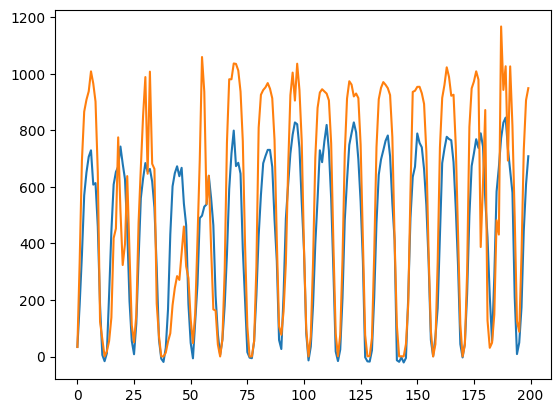

In [13]:
plt.plot(y_pred[:200])
plt.plot(test_y.to_numpy()[:200])